In [201]:
#Imports:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re 


In [210]:
#Load the data
df= pd.read_csv('/Users/preciousajilore/Documents/GitHub/torchmtlr/notebooks/x_before_with_outcomes.csv')

In [214]:
excelSheet = pd.ExcelFile('/Users/preciousajilore/Documents/GitHub/torchmtlr/notebooks/first_cleaned.xlsx')
print(excelSheet.sheet_names)

df_main = pd.read_excel(
                  excelSheet,         #  name of the excel file
                  sheet_name='Sheet1', #   name of the sheet you want to read
                  engine='openpyxl')

['Sheet1']


In [219]:
if df.index.equals(df_main.index):
    print("Indexes are aligned!")
else:
    print("Indexes are NOT aligned!")

Indexes are aligned!


In [220]:
df_main.columns

Index(['Age_calc', 'Date of Surgery', 'COPD', 'Diabetes', 'COPD.1', 'Smoker',
       'Abx', 'Transection', 'Failure', 'fu', 'datetofailureorfollowup',
       'ER visits', 'UTI  Post', 'UTI  recurring', 'foley', 'failure date'],
      dtype='object')

In [227]:

df["datetofailureorfollowup"] = df_main["datetofailureorfollowup"]
df["Date of Surgery"] = df_main["Date of Surgery"]
df["fu"] = df_main["fu"]

In [228]:
df.columns

Index(['Unnamed: 0', 'stxlocation', 'distal', 'penile', 'stxetiology',
       'stxlength', '#strictures', 'charlsons', 'cormorbidity', 'diabetes',
       'copd', 'smoker', 'bmi35+', 'bmiexact', 'prevprocedure',
       '#prevprocedures', 'cysto', 'open', 'ordate', 'urine', 'failure',
       'patent', 'satisfaction', 'datetofailureorfollowup', 'Date of Surgery',
       'time_to_event', 'fu'],
      dtype='object')

In [229]:
df['Date of Surgery'] = pd.to_datetime(df['Date of Surgery'])
df['datetofailureorfollowup'] = pd.to_datetime(df['datetofailureorfollowup'])


In [231]:
# Convert 'fu' to datetime, errors become NaT (pandas' datetime missing value)
df["fu"] = pd.to_datetime(df["fu"], errors='coerce')

In [233]:
# 3. Calculate time to event (in days)
df["time_to_event"] = (df["fu"] - df["Date of Surgery"]).dt.days  #days


In [225]:
df.columns

Index(['Unnamed: 0', 'stxlocation', 'distal', 'penile', 'stxetiology',
       'stxlength', '#strictures', 'charlsons', 'cormorbidity', 'diabetes',
       'copd', 'smoker', 'bmi35+', 'bmiexact', 'prevprocedure',
       '#prevprocedures', 'cysto', 'open', 'ordate', 'urine', 'failure',
       'patent', 'satisfaction', 'datetofailureorfollowup', 'Date of Surgery',
       'time_to_event'],
      dtype='object')

In [234]:
df

,Unnamed: 0,stxlocation,distal,penile,stxetiology,stxlength,#strictures,charlsons,cormorbidity,diabetes,...,open,ordate,urine,failure,patent,satisfaction,datetofailureorfollowup,Date of Surgery,time_to_event,fu
0,0,0,0,1.0,2,3.5,1,0,1.0,1,...,0,2003-08-05 00:00:00,0,0,1.0,NaN,1970-01-01 00:00:00.000000049,2003-08-05,5148.0,2017-09-08
1,1,0,0,1.0,4,5,1,0,0.0,0,...,1,2003-08-06 00:00:00,1,0,1.0,yes,1970-01-01 00:00:00.000000212,2003-08-06,2563.0,2010-08-12
2,2,2,0,0.0,1,3,1,0,0.0,0,...,0,2003-08-21 00:00:00,0,0,1.0,yes,1970-01-01 00:00:00.000000212,2003-08-21,NaN,NaT
3,3,0,0,1.0,4,6.5,1,0,0.0,0,...,1,2003-08-28 00:00:00,0,1,1.0,yes,1970-01-01 00:00:00.000000060,2003-08-28,4282.0,2015-05-19
4,4,1,0,0.0,1,1,1,1,1.0,0,...,0,2003-08-28 00:00:00,0,0,1.0,Not patient died approx 1.5 years post op from...,1970-01-01 00:00:00.000000212,2003-08-28,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1982,1982,1,0,0.0,0,5,1,0,NaN,0,...,0,NaN,0,0,1.0,1,1970-01-01 00:00:00.000000002,2024-02-14,62.0,2024-04-16
1983,1983,3,1,1.0,0,12,1,0,NaN,0,...,0,NaN,0,0,NaN,NaN,1970-01-01 00:00:00.000000001,2024-02-14,30.0,2024-03-15
1984,1984,2,0,0.0,4,4,1,0,NaN,0,...,1,NaN,0,0,NaN,NaN,1970-01-01 00:00:00.000000000,2024-02-23,NaN,NaT
1985,1985,3,1,1.0,5,14,1,0,NaN,0,...,1,NaN,0,0,2.0,1,1970-01-01 00:00:00.000000003,2024-02-26,93.0,2024-05-29


In [235]:
df[df["failure"] == 1]

,Unnamed: 0,stxlocation,distal,penile,stxetiology,stxlength,#strictures,charlsons,cormorbidity,diabetes,...,open,ordate,urine,failure,patent,satisfaction,datetofailureorfollowup,Date of Surgery,time_to_event,fu
3,3,0,0,1.0,4,6.5,1,0,0.0,0,...,1,2003-08-28 00:00:00,0,1,1.0,yes,1970-01-01 00:00:00.000000060,2003-08-28,4282.0,2015-05-19
8,8,1,0,0.0,5,5,1,0,0.0,0,...,0,2003-11-10 00:00:00,0,1,0.0,NaN,1970-01-01 00:00:00.000000006,2003-11-10,372.0,2004-11-16
9,9,1,0,0.0,1,5,1,0,0.0,0,...,0,2003-11-10 00:00:00,0,1,0.0,NaN,1970-01-01 00:00:00.000000006,2003-11-10,NaN,NaT
15,15,1,1,0.0,3,6,1,2,1.0,0,...,1,2004-01-19 00:00:00,0,1,0.0,yes,1970-01-01 00:00:00.000000006,2004-01-19,2486.0,2010-11-09
20,20,3,1,1.0,2,15,1,2,1.0,0,...,1,2004-02-05 00:00:00,0,1,0.0,no,1970-01-01 00:00:00.000000022,2004-02-05,755.0,2006-03-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1922,1922,3,1,1.0,6,10,1,1,1.0,1,...,0,2023-06-22 00:00:00,0,1,1.0,1,1970-01-01 00:00:00.000000005,2023-06-22,169.0,2023-12-08
1929,1929,3,1,1.0,priapism,13,1,1,NaN,1,...,0,NaN,1,1,1.0,1,1970-01-01 00:00:00.000000004,2023-07-11,141.0,2023-11-29
1931,1931,2,0,0.0,3,3,1,2,NaN,0,...,0,NaN,0,1,1.0,1,1970-01-01 00:00:00.000000004,2023-07-21,133.0,2023-12-01
1943,1943,3,1,1.0,2,18,1,0,NaN,0,...,0,NaN,0,1,0.0,1,1970-01-01 00:00:00.000000003,2023-09-05,197.0,2024-03-20


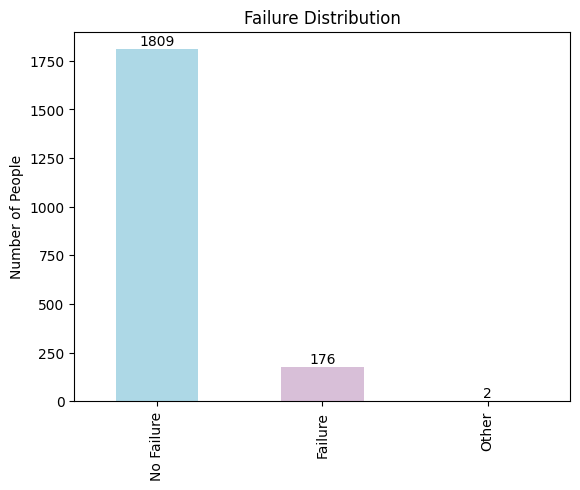

No Failure    1809
Failure        176
Other            2
Name: count, dtype: int64


In [237]:
# Count each value
# Define the order and labels for all expected values
failure_vals = [0, 1, 2]
failure_labels = ['No Failure', 'Failure', 'Other']
colors = ['lightblue', 'thistle', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
counts = df['failure'].value_counts().sort_index().reindex(failure_vals, fill_value=0)
counts.index = failure_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = counts.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Failure Distribution')

# Add text labels
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(counts)

In [238]:

for col_name in df.columns:
    print(col_name)
    print(df[col_name].values)


Unnamed: 0
[   0    1    2 ... 1984 1985 1986]
stxlocation
['0' '0' '2' ... '2' '3' '1']
distal
[0 0 0 ... 0 1 0]
penile
[1. 1. 0. ... 0. 1. 0.]
stxetiology
['2' '4' '1' ... '4' '5' '0']
stxlength
['3.5' '5' '3' ... '4' '14' '4.5']
#strictures
[1 1 1 ... 1 1 1]
charlsons
[0 0 0 ... 0 0 0]
cormorbidity
[ 1.  0.  0. ... nan nan nan]
diabetes
[1 0 0 ... 0 0 0]
copd
[0 0 0 ... 0 0 0]
smoker
[2 0 2 ... 2 2 0]
bmi35+
[0 0 0 ... 0 0 0]
bmiexact
[nan nan nan ... nan nan '33']
prevprocedure
[1. 1. 0. ... 1. 1. 1.]
#prevprocedures
['3' '5' '0' ... '2' '5' '1']
cysto
[2 2 0 ... 0 0 0]
open
['0' '1' '0' ... '1' '1' '0']
ordate
['2003-08-05 00:00:00' '2003-08-06 00:00:00' '2003-08-21 00:00:00' ... nan
 nan nan]
urine
['0' '1' '0' ... '0' '0' '0']
failure
[0 0 0 ... 0 0 0]
patent
[ 1.  1.  1. ... nan  2.  2.]
satisfaction
[nan 'yes' 'yes' ... nan '1' nan]
datetofailureorfollowup
['1970-01-01T00:00:00.000000049' '1970-01-01T00:00:00.000000212'
 '1970-01-01T00:00:00.000000212' ... '1970-01-01T00:00:00

In [239]:
failure_rate = df['failure'].mean() * 100
print(f"Percentage of people with failure: {failure_rate:.2f}%")

Percentage of people with failure: 9.06%


In [240]:
print(df["#prevprocedures"].unique())

['3' '5' '0' '10' '2' '1' '4' '7' '6' '20' '12' '11' nan '8' '13' '50'
 '40' '15' '22' '100' '9' '14' 'slef dilations' 'multiples' 'mulitple'
 'Nr' 'NR' '18']


In [241]:
def clean_prevprocedure(val):
    # Convert to string and lower for comparison
    v = str(val).lower().strip()
    if v in ['multiples', 'mulitple', 'slef dilations']:
        return 5.0
    if v in ['nr', 'nan', '', 'none', 'nan   8']:
        return np.nan
    try:
        return float(v)
    except:
        return np.nan
    

In [242]:
df['#prevprocedures'] = df['#prevprocedures'].apply(clean_prevprocedure)

In [243]:
print(df["#prevprocedures"].unique())

[  3.   5.   0.  10.   2.   1.   4.   7.   6.  20.  12.  11.  nan   8.
  13.  50.  40.  15.  22. 100.   9.  14.  18.]


In [244]:
print(df["#prevprocedures"].dropna().unique())

[  3.   5.   0.  10.   2.   1.   4.   7.   6.  20.  12.  11.   8.  13.
  50.  40.  15.  22. 100.   9.  14.  18.]


In [245]:
df = df.dropna(subset=["#prevprocedures"])

In [246]:
print(df["#prevprocedures"].unique())

[  3.   5.   0.  10.   2.   1.   4.   7.   6.  20.  12.  11.   8.  13.
  50.  40.  15.  22. 100.   9.  14.  18.]


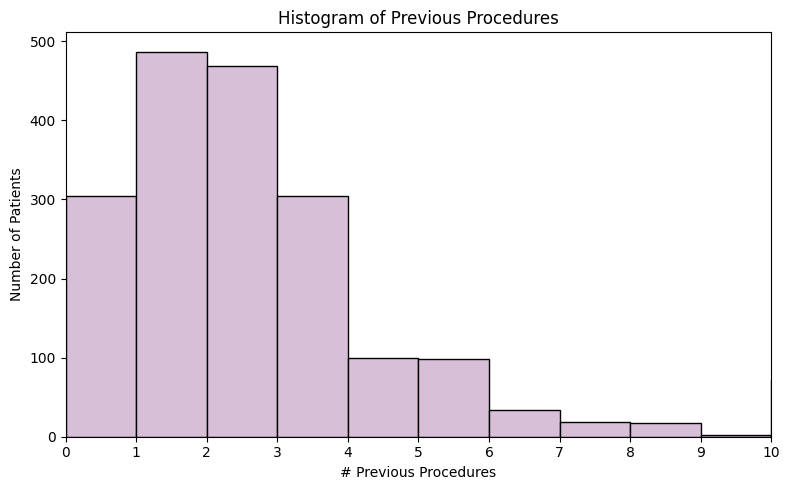

In [247]:

proc = df["#prevprocedures"].dropna().astype(int)
bins = range(proc.min(), proc.max() + 2)

plt.figure(figsize=(8, 5))
plt.hist(proc, bins=bins, edgecolor='black', color='thistle')
plt.xlabel('# Previous Procedures')
plt.ylabel('Number of Patients')
plt.title('Histogram of Previous Procedures')
plt.xticks(range(0, 11))       # Show ticks 0–10 on x-axis
plt.xlim(0, 10)                # Only show 0 to 10 on x-axis
plt.tight_layout()


plt.show()

In [248]:
# Count values 0–10 (you can adjust this range)
proc = df["#prevprocedures"].dropna().astype(int)
value_counts = proc.value_counts().sort_index()

# Limit to 0–10 (most frequent)
value_counts = value_counts.loc[(value_counts.index >= 0) & (value_counts.index <= 100)]

# Calculate percentages
total = value_counts.sum()
percentages = 100 * value_counts / total

# Combine into a table
summary_table = pd.DataFrame({
    'Count': value_counts,
    'Percentage': percentages.round(2)
})

print(summary_table)


                 Count  Percentage
#prevprocedures                   
0                  304       15.72
1                  487       25.18
2                  469       24.25
3                  304       15.72
4                   99        5.12
5                   98        5.07
6                   34        1.76
7                   19        0.98
8                   17        0.88
9                    2        0.10
10                  72        3.72
11                   2        0.10
12                   6        0.31
13                   2        0.10
14                   1        0.05
15                   1        0.05
18                   1        0.05
20                   7        0.36
22                   1        0.05
40                   3        0.16
50                   3        0.16
100                  2        0.10


In [249]:
print(df["copd"].unique())

[0 1]


In [250]:
# Count values 0–10 (you can adjust this range)
copd_detail = df["copd"].dropna().astype(int)
value_counts = copd_detail.value_counts().sort_index()

# Limit to 0–10 (most frequent)
value_counts = value_counts.loc[(value_counts.index >= 0) & (value_counts.index <= 1)]

# Calculate percentages
total = value_counts.sum()
percentages = 100 * value_counts / total

# Combine into a table
summary_table = pd.DataFrame({
    'Count': value_counts,
    'Percentage': percentages.round(2)
})

print(summary_table)

      Count  Percentage
copd                   
0      1862       96.28
1        72        3.72


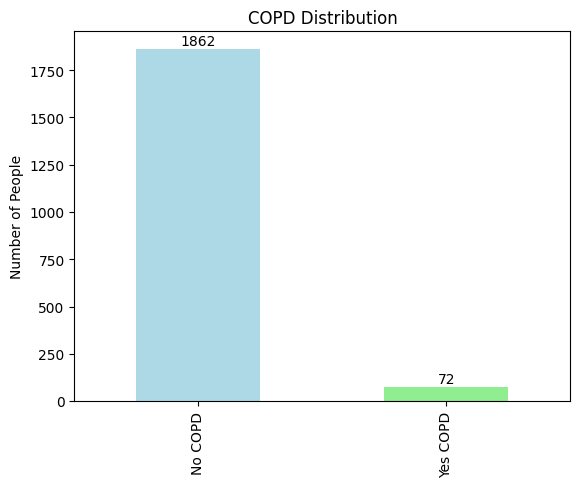

No COPD     1862
Yes COPD      72
Name: count, dtype: int64


In [251]:
# Count each value
# Define the order and labels for all expected values
copd_vals = [0, 1]
copd_labels = ['No COPD', 'Yes COPD']
colors = ['lightblue', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
count = df['copd'].value_counts().sort_index().reindex(copd_vals, fill_value=0)
count.index = copd_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('COPD Distribution')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [252]:
df["smoker"].unique()

array([2, 0, 1])

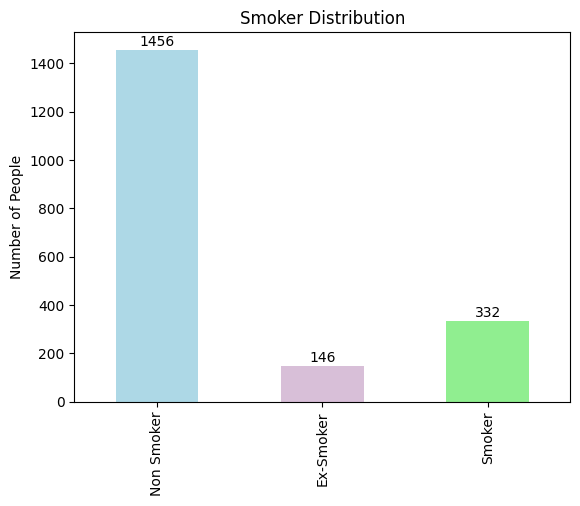

Non Smoker    1456
Ex-Smoker      146
Smoker         332
Name: count, dtype: int64


In [253]:
# Count each value
# Define the order and labels for all expected values
smoker_vals = [0, 1, 2]
smoker_labels = ['Non Smoker', 'Ex-Smoker', 'Smoker']
colors = ['lightblue', 'thistle', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
counts = df['smoker'].value_counts().sort_index().reindex(smoker_vals, fill_value=0)
counts.index = smoker_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax = counts.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Smoker Distribution')

# Add text labels
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(counts)

Unnamed: 0
[   0    1    2 ... 1984 1985 1986]
stxlocation
['0' '0' '2' ... '2' '3' '1']
distal
[0 0 0 ... 0 1 0]
penile
[1. 1. 0. ... 0. 1. 0.]
stxetiology
['2' '4' '1' ... '4' '5' '0']
stxlength
['3.5' '5' '3' ... '4' '14' '4.5']
#strictures
[1 1 1 ... 1 1 1]
charlsons
[0 0 0 ... 0 0 0]
cormorbidity
[ 1.  0.  0. ... nan nan nan]
diabetes
[1 0 0 ... 0 0 0]
copd
[0 0 0 ... 0 0 0]
smoker
[2 0 2 ... 2 2 0]
bmi35+
[0 0 0 ... 0 0 0]
bmiexact
[nan nan nan ... nan nan '33']
prevprocedure
[1. 1. 0. ... 1. 1. 1.]
#prevprocedures
['3' '5' '0' ... '2' '5' '1']
cysto
[2 2 0 ... 0 0 0]
open
['0' '1' '0' ... '1' '1' '0']
ordate
['2003-08-05 00:00:00' '2003-08-06 00:00:00' '2003-08-21 00:00:00' ... nan
 nan nan]
urine
['0' '1' '0' ... '0' '0' '0']
failure
[0 0 0 ... 0 0 0]
patent
[ 1.  1.  1. ... nan  2.  2.]
satisfaction
[nan 'yes' 'yes' ... nan '1' nan]

In [254]:
df["open"].unique()

array(['0', '1', 'no ', 'Yes ', 'no'], dtype=object)

In [255]:
def clean_open(val):
    # Convert to string and lower for comparison
    v = str(val).lower().strip()
    print(f"Value: {v!r}")  # Print each value as it's processed

    if v in ['0', 'no', "No"]:
        return 0
    if v in ['1', 'Yes']:
        return 1
    #return np.nan


In [256]:
df["open"].unique()

array(['0', '1', 'no ', 'Yes ', 'no'], dtype=object)

In [257]:
df["open_clean"] = df["open"].apply(clean_open).dropna()

Value: '0'
Value: '1'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '1'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '1'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '1'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: 'no'
Value: '0

/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_11677/792182288.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["open_clean"] = df["open"].apply(clean_open).dropna()


In [258]:
df["open_clean"].unique()

array([ 0.,  1., nan])

In [259]:
print(df["open"].unique())

['0' '1' 'no ' 'Yes ' 'no']


In [260]:
df = df.dropna(subset=['open_clean'])

In [261]:
print(df["open_clean"].unique())

[0. 1.]


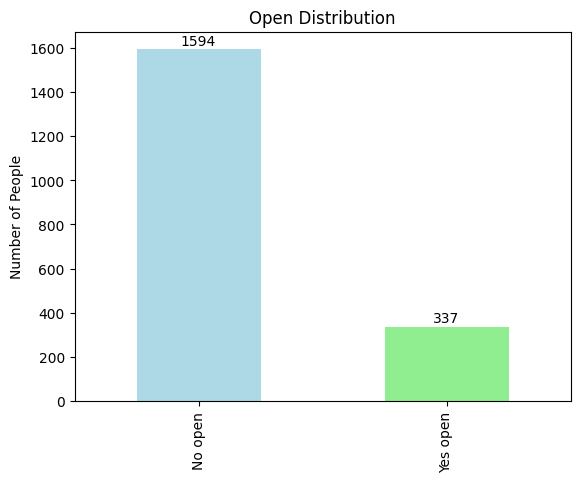

No open     1594
Yes open     337
Name: count, dtype: int64


In [264]:
# Count each value
# Define the order and labels for all expected values
open_vals = [0, 1]
open_labels = ['No open', 'Yes open']
colors = ['lightblue', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
count = df['open_clean'].value_counts().sort_index().reindex(open_vals, fill_value=0)
count.index = open_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Open Distribution')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [263]:
print(df["diabetes"].unique())

[1 0]


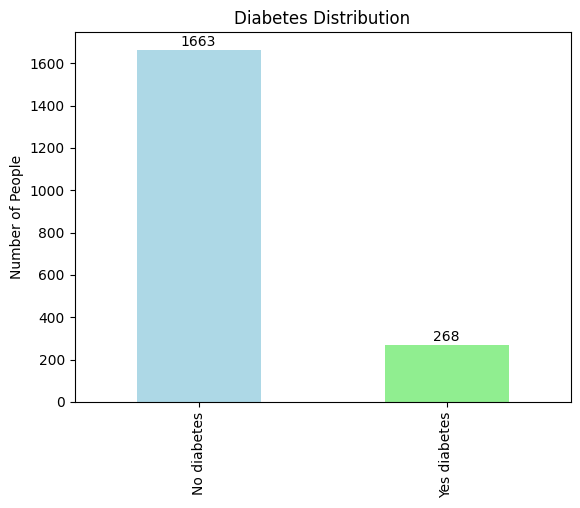

No diabetes     1663
Yes diabetes     268
Name: count, dtype: int64


In [265]:
# Count each value
# Define the order and labels for all expected values
diabetes_vals = [0, 1]
diabetes_labels = ['No diabetes', 'Yes diabetes']
colors = ['lightblue', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
count = df['diabetes'].value_counts().sort_index().reindex(diabetes_vals, fill_value=0)
count.index = diabetes_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Diabetes Distribution')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [266]:
print(df["cormorbidity"].unique())

[ 1.  0. nan]


In [267]:
df = df.dropna(subset=['cormorbidity'])

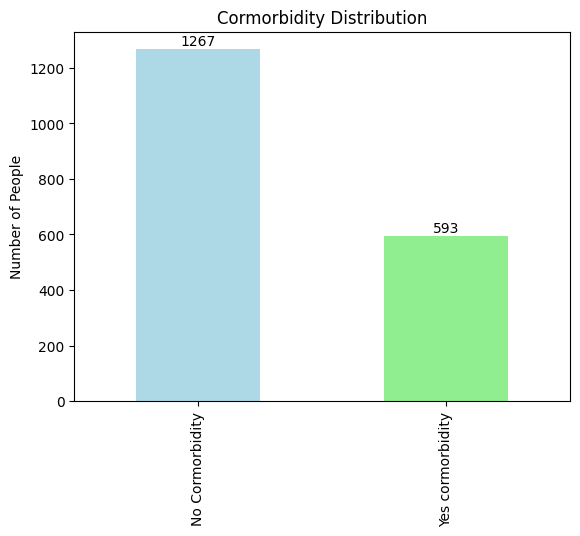

No Cormorbidity     1267
Yes cormorbidity     593
Name: count, dtype: int64


In [268]:
# Count each value
# Define the order and labels for all expected values
corm_vals = [0, 1]
corm_labels = ['No Cormorbidity', 'Yes cormorbidity']
colors = ['lightblue', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
count = df['cormorbidity'].value_counts().sort_index().reindex(corm_vals, fill_value=0)
count.index = corm_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Cormorbidity Distribution')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [269]:
print(df["charlsons"].unique())

[ 0  1  2  5  3  4  6  7 11]


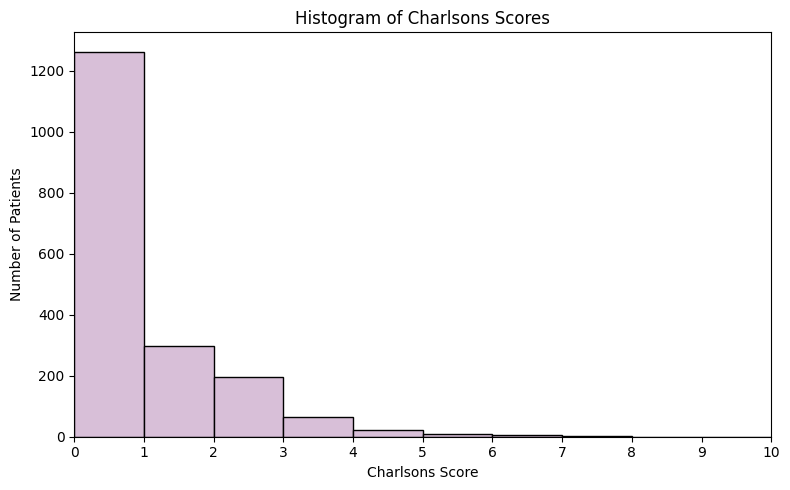

In [270]:

proc = df["charlsons"]
bins = range(proc.min(), proc.max() + 2)

plt.figure(figsize=(8, 5))
plt.hist(proc, bins=bins, edgecolor='black', color='thistle')
plt.xlabel('Charlsons Score')
plt.ylabel('Number of Patients')
plt.title('Histogram of Charlsons Scores')
plt.xticks(range(0, 12))       # Show ticks 0–10 on x-axis
plt.xlim(0, 10)                # Only show 0 to 10 on x-axis
plt.tight_layout()


plt.show()

In [271]:
# Count values 0–10 (you can adjust this range)

value_counts = proc.value_counts().sort_index()

# Limit to 0–10 (most frequent)
value_counts = value_counts.loc[(value_counts.index >= 0) & (value_counts.index <= 100)]

# Calculate percentages
total = value_counts.sum()
percentages = 100 * value_counts / total

# Combine into a table
summary_table = pd.DataFrame({
    'Count': value_counts,
    'Percentage': percentages.round(2)
})

print(summary_table)

           Count  Percentage
charlsons                   
0           1262       67.85
1            297       15.97
2            197       10.59
3             66        3.55
4             21        1.13
5              9        0.48
6              5        0.27
7              2        0.11
11             1        0.05


In [272]:
print(df["#strictures"].unique())

[1 2]


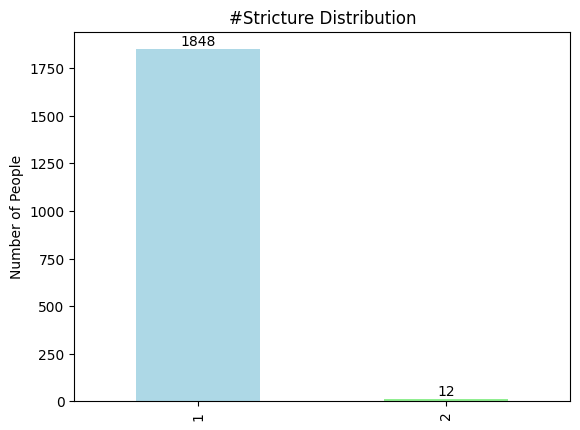

1    1848
2      12
Name: count, dtype: int64


In [273]:
# Count each value
# Define the order and labels for all expected values
str_vals = [1, 2]
str_labels = ['1', '2']
colors = ['lightblue', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
count = df['#strictures'].value_counts().sort_index().reindex(str_vals, fill_value=0)
count.index = str_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('#Stricture Distribution')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [274]:
df.columns

Index(['Unnamed: 0', 'stxlocation', 'distal', 'penile', 'stxetiology',
       'stxlength', '#strictures', 'charlsons', 'cormorbidity', 'diabetes',
       'copd', 'smoker', 'bmi35+', 'bmiexact', 'prevprocedure',
       '#prevprocedures', 'cysto', 'open', 'ordate', 'urine', 'failure',
       'patent', 'satisfaction', 'datetofailureorfollowup', 'Date of Surgery',
       'time_to_event', 'fu', 'open_clean'],
      dtype='object')

In [275]:
print(df["stxlength"].unique())

['3.5' '5' '3' '6.5' '1' '1.5' '2' '5.5' '6' '4' '2.5' '15' '12' '16' '11'
 '9' '7' '18' '4.5' '10' '20' '8' '22' '14' '13' '19' '7.5' '17' '21'
 '0.5' '4 bulbar and 2 penile' '8.5' '10 (penobulbar) + 1,5 (bulbar)']


In [277]:
def split_lengths(val):
    if pd.isna(val):
        return (0.0, 0.0)
    s = str(val)
    nums = re.findall(r'[\d]+[.,]?[\d]*', s)
    nums = [n.replace(',', '.') for n in nums]
    nums = [float(n) for n in nums]
    if len(nums) == 1:
        return (nums[0], 0.0)
    elif len(nums) >= 2:
        return (nums[0], nums[1])
    else:
        return (0.0, 0.0)

In [278]:
df[['stxlength_1', 'stxlength_2']] = df['stxlength'].apply(split_lengths).apply(pd.Series)


In [279]:
df['stxlength_2'].unique()

array([0. , 2. , 1.5])

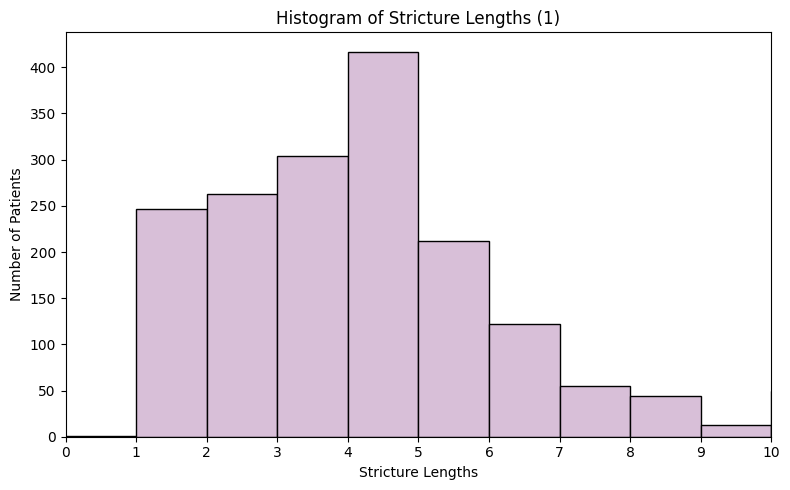

In [280]:

proc = df["stxlength_1"].astype(int)
bins = range(proc.min(), proc.max() + 2)

plt.figure(figsize=(8, 5))
plt.hist(proc, bins=bins, edgecolor='black', color='thistle')
plt.xlabel('Stricture Lengths')
plt.ylabel('Number of Patients')
plt.title('Histogram of Stricture Lengths (1)')
plt.xticks(range(0, 12))       # Show ticks 0–10 on x-axis
plt.xlim(0, 10)                # Only show 0 to 10 on x-axis
plt.tight_layout()


plt.show()

In [281]:
# Count values 0–10 (you can adjust this range)

value_counts = proc.value_counts().sort_index()

# Limit to 0–10 (most frequent)
value_counts = value_counts.loc[(value_counts.index >= 0) & (value_counts.index <= 100)]

# Calculate percentages
total = value_counts.sum()
percentages = 100 * value_counts / total

# Combine into a table
summary_table = pd.DataFrame({
    'Count': value_counts,
    'Percentage': percentages.round(2)
})

print(summary_table)

             Count  Percentage
stxlength_1                   
0                1        0.05
1              247       13.28
2              263       14.14
3              304       16.34
4              417       22.42
5              212       11.40
6              122        6.56
7               55        2.96
8               44        2.37
9               13        0.70
10              49        2.63
11              20        1.08
12              39        2.10
13              10        0.54
14              23        1.24
15               6        0.32
16              12        0.65
17               2        0.11
18              14        0.75
19               3        0.16
20               2        0.11
21               1        0.05
22               1        0.05


In [282]:
print(df["stxetiology"].unique())

['2' '4' '1' '0' '5' '3' '6' '2,4' '6 (chlamydia treated at age 18)']


In [283]:
def split_etiology(val):
    if pd.isna(val):
        return (0, 0)
    s = str(val)
    # Find all integers in the string
    nums = re.findall(r'\d+', s)
    nums = [int(n) for n in nums]
    if len(nums) == 1:
        return (nums[0], 0)
    elif len(nums) >= 2:
        return (nums[0], nums[1])
    else:
        return (0, 0)

In [284]:
df[['stxetiology_1', 'stxetiology_2']] = df['stxetiology'].apply(split_etiology).apply(pd.Series)


In [285]:
print(df["stxetiology_1"].unique())

[2 4 1 0 5 3 6]


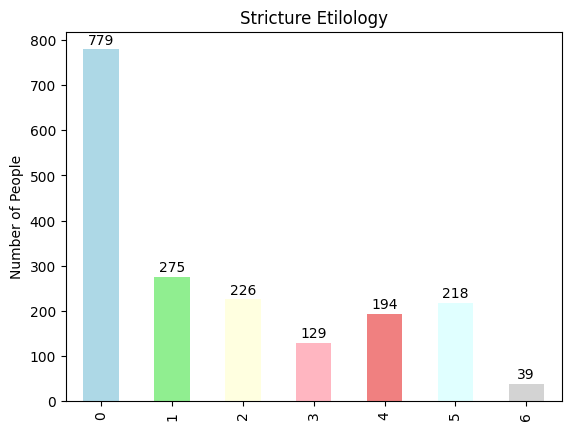

0    779
1    275
2    226
3    129
4    194
5    218
6     39
Name: count, dtype: int64


In [286]:
# Count each value
# Define the order and labels for all expected values
etx_vals = [0, 1, 2, 3, 4, 5, 6]
etx_labels = ['0','1', '2', '3', '4', '5', '6']
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightpink', 'lightcoral', 'lightcyan', 'lightgray']

# Count occurrences, reindex to include zeros for missing classes
count = df['stxetiology_1'].value_counts().sort_index().reindex(etx_vals, fill_value=0)
count.index = etx_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Stricture Etilology')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [287]:
print(df["stxlocation"].unique())

['0' '2' '1' '3' '4' '5' '0 and 1' '1 and 4']


In [288]:
df[['stxlocation_1', 'stxlocation_2']] = df['stxlocation'].apply(split_etiology).apply(pd.Series)


In [289]:
print(df["stxlocation_1"].unique())

[0 2 1 3 4 5]


In [290]:
print(df["stxlocation_2"].unique())

[0 1 4]


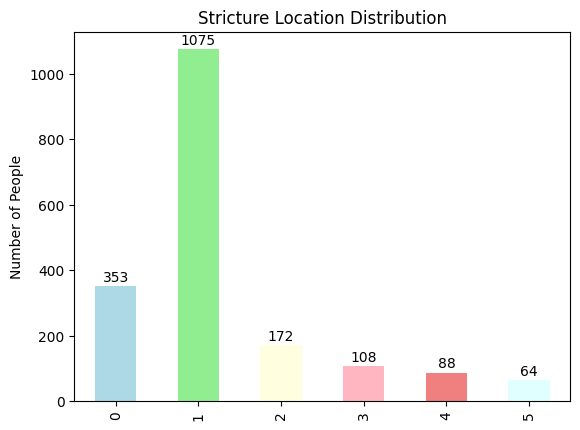

0     353
1    1075
2     172
3     108
4      88
5      64
Name: count, dtype: int64


In [291]:
# Count each value
# Define the order and labels for all expected values
loc_vals = [0, 1, 2, 3, 4, 5]
loc_labels = ['0','1', '2', '3', '4', '5']
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightpink', 'lightcoral', 'lightcyan']

# Count occurrences, reindex to include zeros for missing classes
count = df['stxlocation_1'].value_counts().sort_index().reindex(loc_vals, fill_value=0)
count.index = loc_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Stricture Location Distribution')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [292]:
df[df["distal"] == 11]

,Unnamed: 0,stxlocation,distal,penile,stxetiology,stxlength,#strictures,charlsons,cormorbidity,diabetes,...,Date of Surgery,time_to_event,fu,open_clean,stxlength_1,stxlength_2,stxetiology_1,stxetiology_2,stxlocation_1,stxlocation_2
1035,1035,4,11,1.0,3,7,1,7,1.0,0,...,2016-05-10,21.0,2016-05-31,0.0,7.0,0.0,3,0,4,0


In [293]:
df[df["distal"] == 11].count()

Unnamed: 0                 1
stxlocation                1
distal                     1
penile                     1
stxetiology                1
stxlength                  1
#strictures                1
charlsons                  1
cormorbidity               1
diabetes                   1
copd                       1
smoker                     1
bmi35+                     1
bmiexact                   0
prevprocedure              1
#prevprocedures            1
cysto                      1
open                       1
ordate                     1
urine                      1
failure                    1
patent                     1
satisfaction               0
datetofailureorfollowup    1
Date of Surgery            1
time_to_event              1
fu                         1
open_clean                 1
stxlength_1                1
stxlength_2                1
stxetiology_1              1
stxetiology_2              1
stxlocation_1              1
stxlocation_2              1
dtype: int64

In [294]:
df.loc[df['distal'] == 11, 'distal'] = 1

In [295]:
print(df["distal"].unique())

[0 1]


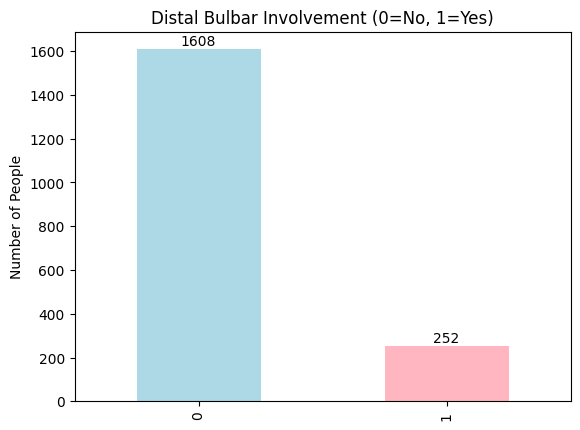

0    1608
1     252
Name: count, dtype: int64


In [296]:
# Count each value
# Define the order and labels for all expected values
dist_vals = [0, 1]
dist_labels = ['0','1']
colors = ['lightblue',  'lightpink']

# Count occurrences, reindex to include zeros for missing classes
count = df['distal'].value_counts().sort_index().reindex(dist_vals, fill_value=0)
count.index = dist_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Distal Bulbar Involvement (0=No, 1=Yes)')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [297]:
print(df["penile"].unique())

[ 1.  0. nan]


In [298]:
df = df.dropna(subset="penile")

In [299]:
print(df["penile"].unique())

[1. 0.]


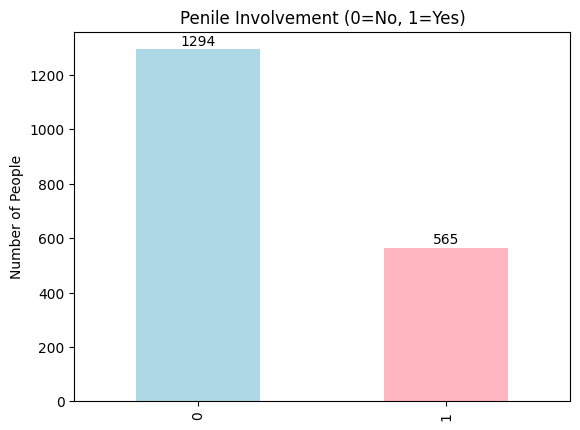

0    1294
1     565
Name: count, dtype: int64


In [300]:
# Count each value
# Define the order and labels for all expected values
pen_vals = [0, 1]
pen_labels = ['0','1']
colors = ['lightblue',  'lightpink']

# Count occurrences, reindex to include zeros for missing classes
count = df['penile'].value_counts().sort_index().reindex(pen_vals, fill_value=0)
count.index = pen_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Penile Involvement (0=No, 1=Yes)')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [301]:
#Find the amount of null values in each col
print(df.isnull().sum())

Unnamed: 0                    0
stxlocation                   0
distal                        0
penile                        0
stxetiology                   0
stxlength                     0
#strictures                   0
charlsons                     0
cormorbidity                  0
diabetes                      0
copd                          0
smoker                        0
bmi35+                        0
bmiexact                   1015
prevprocedure                 0
#prevprocedures               0
cysto                         0
open                          0
ordate                        4
urine                         0
failure                       0
patent                        1
satisfaction                650
datetofailureorfollowup       0
Date of Surgery               0
time_to_event               174
fu                          174
open_clean                    0
stxlength_1                   0
stxlength_2                   0
stxetiology_1                 0
stxetiol

In [302]:
print(df["bmiexact"].unique())

[nan '38' '40' '42' '39' '41' '36' '37' '35' '50' '54' '30'
 '21.90041658401111' '39.7' '45' '34.1' '38.9' '41.8' '41.5' '45.7' '43'
 '34.77' '45.2' '34' '46.1' '18.2647023306364' '35.7' '26.7' '35.5'
 '31.02132278281573' '49.3' '44.8' '20.5191340925413' '41.3'
 '35.74962494813112' '36.3' '24.10688651317683' '44.7' '59' '36.4' '45.5'
 '41.2' '49.5' '45.3' '47.1' '49.1' '35.4' '48.2' '38.6' '27.1' '31.8'
 '58' '29.1' '30.7' '29.2' '24.5' '35.6' '35.2' '29' '36.9' '28.6' '64'
 '24.6' '42.9' '71' '34.2' '28.8' '30.3' '36.8' '27.2' '28.1' '32.5'
 '35.8' '23.4' '26.5' '24.9' '22.2' '29.3' '28.7' '31.1' '31.2' '26.2'
 '49.2' '28.9' '42.8' '21.9' '25.7' '36.2' '25.9' '31.9' '39.3' '32.4'
 '43.6' '30.9' '31' '27' '37.7' '34.9' '37.6' '24' '67.2' '28.5' '43.4'
 '21.3' '28.3' '26' '53.7' '30.4' '34.5' '27.9' '23' '31.5' '32.2' '23.9'
 '29.7' '?' '24.3' '25.5' '21.4' '29.5' '24.2' '29.6' '44.9' '33.1' '25'
 '32.9' '24.8' '26.9' '25.3' '36.6' '26.1' '30.2' '33' '24.7' '30.8'
 '23.6' '43.8' '40.2' 

In [303]:
df = df.dropna(subset=['bmiexact'])

In [304]:
print(df.isnull().sum())

Unnamed: 0                   0
stxlocation                  0
distal                       0
penile                       0
stxetiology                  0
stxlength                    0
#strictures                  0
charlsons                    0
cormorbidity                 0
diabetes                     0
copd                         0
smoker                       0
bmi35+                       0
bmiexact                     0
prevprocedure                0
#prevprocedures              0
cysto                        0
open                         0
ordate                       4
urine                        0
failure                      0
patent                       0
satisfaction               295
datetofailureorfollowup      0
Date of Surgery              0
time_to_event              120
fu                         120
open_clean                   0
stxlength_1                  0
stxlength_2                  0
stxetiology_1                0
stxetiology_2                0
stxlocat

In [305]:
df.columns

Index(['Unnamed: 0', 'stxlocation', 'distal', 'penile', 'stxetiology',
       'stxlength', '#strictures', 'charlsons', 'cormorbidity', 'diabetes',
       'copd', 'smoker', 'bmi35+', 'bmiexact', 'prevprocedure',
       '#prevprocedures', 'cysto', 'open', 'ordate', 'urine', 'failure',
       'patent', 'satisfaction', 'datetofailureorfollowup', 'Date of Surgery',
       'time_to_event', 'fu', 'open_clean', 'stxlength_1', 'stxlength_2',
       'stxetiology_1', 'stxetiology_2', 'stxlocation_1', 'stxlocation_2'],
      dtype='object')

In [307]:
df = df.dropna(subset=['time_to_event'])

In [310]:
print(df.isna().sum())
df = df.dropna(subset=['failure', 'time_to_event'])

Unnamed: 0                   0
stxlocation                  0
distal                       0
penile                       0
stxetiology                  0
stxlength                    0
#strictures                  0
charlsons                    0
cormorbidity                 0
diabetes                     0
copd                         0
smoker                       0
bmi35+                       0
bmiexact                     0
prevprocedure                0
#prevprocedures              0
cysto                        0
open                         0
ordate                       3
urine                        0
failure                      0
patent                       0
satisfaction               179
datetofailureorfollowup      0
Date of Surgery              0
time_to_event                0
fu                           0
open_clean                   0
stxlength_1                  0
stxlength_2                  0
stxetiology_1                0
stxetiology_2                0
stxlocat

In [315]:
print(df["time_to_event"].describe())
print(df[df["time_to_event"] < 0][["Date of Surgery", "fu", "time_to_event"]])


count     724.000000
mean      384.062155
std       560.066297
min      -464.000000
25%       116.000000
50%       205.000000
75%       530.000000
max      4679.000000
Name: time_to_event, dtype: float64
     Date of Surgery         fu  time_to_event
1475      2019-09-24 2019-02-07         -229.0
1482      2019-10-08 2019-02-12         -238.0
1609      2020-11-30 2020-06-03         -180.0
1630      2021-02-23 2020-12-29          -56.0
1633      2021-03-08 2021-02-25          -11.0
1635      2021-03-09 2021-01-13          -55.0
1641      2021-03-22 2021-01-12          -69.0
1649      2021-04-06 2021-02-24          -41.0
1667      2021-06-01 2021-05-18          -14.0
1671      2021-06-14 2021-05-05          -40.0
1672      2021-06-14 2021-02-24         -110.0
1674      2021-06-15 2021-05-19          -27.0
1678      2021-06-25 2021-05-19          -37.0
1681      2021-07-05 2021-06-02          -33.0
1682      2021-07-12 2021-06-11          -31.0
1686      2021-08-03 2021-06-16          -48

In [316]:
df = df[df["time_to_event"] >= 0].reset_index(drop=True)

In [317]:
df["time_to_event"].min()

0.0

In [318]:
df.to_csv('x_before_surgery.csv', index = False)

In [312]:
df.columns

Index(['Unnamed: 0', 'stxlocation', 'distal', 'penile', 'stxetiology',
       'stxlength', '#strictures', 'charlsons', 'cormorbidity', 'diabetes',
       'copd', 'smoker', 'bmi35+', 'bmiexact', 'prevprocedure',
       '#prevprocedures', 'cysto', 'open', 'ordate', 'urine', 'failure',
       'patent', 'satisfaction', 'datetofailureorfollowup', 'Date of Surgery',
       'time_to_event', 'fu', 'open_clean', 'stxlength_1', 'stxlength_2',
       'stxetiology_1', 'stxetiology_2', 'stxlocation_1', 'stxlocation_2'],
      dtype='object')